# Micrograd — Backpropagation, Explained in Runnable Code

> Andrej Karpathy. *micrograd: A tiny scalar-valued autograd engine and a neural net library on top of it.*
> [github.com/karpathy/micrograd](https://github.com/karpathy/micrograd) ·
> companion lecture: *“The spelled-out intro to neural networks and backpropagation: building micrograd.”*

This notebook is a **from-scratch, runnable re-implementation** of micrograd. Every component is built
in plain Python and explained **next to the exact piece of calculus it implements**, so you can read the
math and the code side by side and *run* each piece to confirm it behaves as derived.

The entire deep-learning stack — autodiff, a neuron, a multi-layer perceptron, a loss, and gradient
descent — is built out of **one idea**: a scalar that remembers how it was computed, so it can hand the
**chain rule** back through the graph. We finish by *using the network for prediction*: training an MLP to
fit a labelled dataset end to end.

We deliberately **do not** use `torch.autograd` to compute gradients. We build the autograd engine
ourselves, then check it against PyTorch so nothing is hidden.

### How this notebook is organized (mapped to the engine)

| Notebook section | What it builds | The math |
|---|---|---|
| 1. Setup | imports | — |
| 2. The idea: reverse-mode autodiff | overview | chain rule on a DAG |
| 3. The `Value` object | node = data + grad + history | $f$ and $\frac{\partial L}{\partial f}$ |
| 4. Addition | `__add__` | $\frac{\partial}{\partial a}(a{+}b)=1$ |
| 5. Multiplication | `__mul__` | product rule, local $=$ the *other* operand |
| 6. Power | `__pow__` | $\frac{d}{dx}x^{n}=n x^{n-1}$ |
| 7. `exp` and `tanh` | activations | $\frac{d}{dx}e^{x}=e^{x}$, $\tanh'=1-\tanh^{2}$ |
| 8. neg / sub / div | compositions | reuse of the above |
| 9. `backward()` | topological reverse pass | seed $\frac{\partial L}{\partial L}=1$, accumulate |
| 10. The full `Value` class | the engine, assembled | — |
| 11. Build & draw an expression graph | a single neuron's DAG | — |
| 12. Backprop by hand, then automatically | verification | chain rule, step by step |
| 13. Check against PyTorch | external ground truth | — |
| 14. The two classic bugs | `+=` vs `=`, division | why gradients **accumulate** |
| 15. Neuron → Layer → MLP | the network library | $\tanh(\mathbf{w}\cdot\mathbf{x}+b)$ |
| 16. The prediction problem | a labelled dataset | — |
| 17. Loss | mean-squared error | $L=\sum(\hat y-y)^2$ |
| 18. Gradient descent | the training loop | $\theta \leftarrow \theta-\eta\,\nabla_\theta L$ |
| 19. Watch the predictions converge | run it | — |
| 20. Summary: concept → code map | — | — |

**Runtime note:** everything runs on CPU in seconds, with **no external graph tool** — the DAG drawer
below is a self-contained ~30-line matplotlib function, so the notebook runs anywhere `numpy`,
`matplotlib`, and (optionally) `torch` are installed.

## 1. Setup

The engine itself needs nothing but `math`. We add `numpy`/`matplotlib` only to *draw* the computation graph and the loss curve, and `random` to initialize weights.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

random.seed(1337)   # reproducible weight initialization

## 2. The idea — reverse-mode automatic differentiation

To train a neural network we need, for every parameter $\theta$, the number
$\frac{\partial L}{\partial \theta}$ — how much the scalar loss $L$ moves if we nudge $\theta$. With that
number we can take a step *downhill*. The whole game is computing those derivatives **exactly** and
**cheaply**, for an expression with thousands of parameters.

**The computation as a graph.** Any expression — say $L = (a\cdot b + c)\cdot d$ — is a directed acyclic
graph (DAG): leaves are inputs/parameters, internal nodes are the results of `+`, `*`, `tanh`, …, and the
root is $L$. Each edge carries a value forward.

**The chain rule, locally.** Suppose a node $f$ is built from children via $f = g(u, v)$. If we already
know $\frac{\partial L}{\partial f}$ (how the loss depends on $f$), the chain rule says the loss's
sensitivity to a child is

$$\frac{\partial L}{\partial u} \;=\; \frac{\partial L}{\partial f}\;\cdot\;\frac{\partial f}{\partial u}.$$

The first factor is *global* (handed down from above); the second, $\frac{\partial f}{\partial u}$, is a
**local** derivative that depends only on the operation at $f$. So every operation only has to know **how
to differentiate itself**, given the gradient flowing in from above. That local rule is exactly what we
attach to each node as a small `_backward` closure.

**Forward then backward.** Run the graph forward to fill in every `data`. Then visit nodes in **reverse**
topological order (root first), and at each node multiply the incoming $\frac{\partial L}{\partial f}$ by
each local $\frac{\partial f}{\partial u}$ and *add* it into the child's gradient. One pass over the graph
yields **all** parameter gradients — this is *reverse-mode* autodiff, a.k.a. backpropagation.

## 3. The `Value` object — a scalar that remembers how it was made

A `Value` wraps a single floating-point number and records enough history to backpropagate through it:

- **`data`** — the scalar value $f$ produced in the forward pass.
- **`grad`** — the derivative $\frac{\partial L}{\partial f}$ of the *final* output w.r.t. this node.
  It starts at `0.0` (before backprop, the loss doesn't depend on it as far as we know).
- **`_prev`** — the set of child `Value`s this one was computed from (the incoming edges).
- **`_op`** — a string naming the operation (`'+'`, `'*'`, `'tanh'`, …), purely for visualization.
- **`_backward`** — a closure that, *when called*, pushes this node's `grad` into its children's `grad`
  using the local derivative. For a leaf it does nothing.

`grad = 0.0` is not cosmetic: gradients are **accumulated** (`+=`) during the backward pass, because a node
may feed *several* parents and the chain rule says those contributions **add**. We rely on that in §14.

We now derive the `_backward` for each operation in isolation (§4–§8), then assemble the complete class in
§10.

## 4. Addition — `__add__`

Forward: $f = a + b$. Local derivatives are both $1$:

$$\frac{\partial f}{\partial a} = 1, \qquad \frac{\partial f}{\partial b} = 1.$$

So an addition node is a **gradient router**: by the chain rule it copies the incoming gradient,
unchanged, to *both* children.

$$\frac{\partial L}{\partial a} \mathrel{+}= \frac{\partial L}{\partial f}\cdot 1, \qquad
  \frac{\partial L}{\partial b} \mathrel{+}= \frac{\partial L}{\partial f}\cdot 1.$$

```python
def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)   # wrap raw ints/floats
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
        self.grad  += 1.0 * out.grad     # route gradient to both children
        other.grad += 1.0 * out.grad
    out._backward = _backward
    return out
```

(The `other = other if isinstance(...)` line lets us write `x + 1` — the constant `1` gets wrapped as a
`Value` so the graph stays uniform.)

## 5. Multiplication — `__mul__`

Forward: $f = a \cdot b$. By the product rule the local derivative w.r.t. one factor is the **other**
factor:

$$\frac{\partial f}{\partial a} = b, \qquad \frac{\partial f}{\partial b} = a.$$

So a multiply node **swaps and scales**: each child receives the upstream gradient multiplied by the value
of its sibling.

$$\frac{\partial L}{\partial a} \mathrel{+}= b\cdot\frac{\partial L}{\partial f}, \qquad
  \frac{\partial L}{\partial b} \mathrel{+}= a\cdot\frac{\partial L}{\partial f}.$$

```python
def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
        self.grad  += other.data * out.grad   # local derivative = the *other* operand
        other.grad += self.data  * out.grad
    out._backward = _backward
    return out
```

## 6. Power — `__pow__`

Forward: $f = a^{n}$ for a *constant* exponent $n$ (int/float). The power rule gives

$$\frac{\partial f}{\partial a} = n\,a^{\,n-1}.$$

This single method buys us a lot: with it (plus `*`) we get division ($a/b = a\cdot b^{-1}$) and square
roots ($\sqrt a = a^{0.5}$) for free.

```python
def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers"
    out = Value(self.data ** other, (self,), f'**{other}')
    def _backward():
        self.grad += (other * self.data ** (other - 1)) * out.grad   # n * a^(n-1) * upstream
    out._backward = _backward
    return out
```

## 7. Activations — `exp` and `tanh`

Linear combinations alone can only represent linear functions; the **non-linearity** is what lets a
network bend. micrograd's neuron uses $\tanh$.

**`exp`.** Forward $f = e^{x}$. It is its own derivative, $\frac{d}{dx}e^{x}=e^{x}=f$, so the local factor
is just `out.data`:

```python
def exp(self):
    out = Value(math.exp(self.data), (self,), 'exp')
    def _backward():
        self.grad += out.data * out.grad      # d/dx e^x = e^x = out.data
    out._backward = _backward
    return out
```

**`tanh`.** Forward $t = \tanh(x) = \dfrac{e^{2x}-1}{e^{2x}+1}$. Its derivative has the famous closed form

$$\frac{d}{dx}\tanh(x) = 1 - \tanh^{2}(x) = 1 - t^{2}.$$

We already computed $t$ in the forward pass, so the backward pass is one subtraction and one multiply:

```python
def tanh(self):
    t = math.tanh(self.data)
    out = Value(t, (self,), 'tanh')
    def _backward():
        self.grad += (1 - t**2) * out.grad    # 1 - tanh(x)^2, times upstream
    out._backward = _backward
    return out
```

Two subtleties that bite people (we demonstrate both in §14):
1. The `+=` here is **mandatory**, not stylistic — writing `=` silently breaks any graph where a node is
   reused.
2. Because $\tanh$ is implemented as a single primitive with a known derivative, we don't have to
   backprop through the `exp`/divide internals. We *could* also build $\tanh$ out of `exp`, `+`, `/` and
   get the identical gradient — a nice cross-check on the engine.

## 8. Subtraction, negation, division — for free

We don't need new backward rules for these; each is a **composition** of operations we already
differentiated, so the chain rule wires itself up automatically:

$$-a = a\cdot(-1), \qquad a - b = a + (-b), \qquad \frac{a}{b} = a\cdot b^{-1}.$$

```python
def __neg__(self):       return self * -1
def __sub__(self, o):    return self + (-o)
def __truediv__(self, o):return self * o**-1          # NOT self * o  (see §14)
```

We also add the **reflected** operators (`__radd__`, `__rmul__`, …) so Python expressions like `2 * a` or
`1 - a`, where the `Value` is on the *right*, still dispatch into our methods.

## 9. `backward()` — one reverse pass over the whole graph

Each `_backward` only knows how to push gradient one hop, to its direct children. To get **every**
gradient we must call them in the right order: a node's `_backward` may only run **after** its own `grad`
is final, i.e. after *all* its parents have contributed. That ordering is a **reverse topological sort**.

```python
def backward(self):
    topo, visited = [], set()
    def build_topo(v):                 # depth-first post-order = children before parents
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
    build_topo(self)

    self.grad = 1.0                    # seed: dL/dL = 1
    for node in reversed(topo):        # root first, then back toward the leaves
        node._backward()
```

Two lines carry all the meaning:

- **`self.grad = 1.0`** seeds the recursion. The output's derivative with respect to *itself* is
  $\frac{\partial L}{\partial L}=1$; every other gradient is built up from this.
- **`reversed(topo)`** guarantees that when we call a node's `_backward`, its `grad` is already complete,
  so the gradient it routes downward is correct. Combined with the `+=` accumulation inside each
  `_backward`, the contributions from multiple paths to the same node **sum**, exactly as the multivariable
  chain rule requires.

## 10. The full `Value` class — the engine, assembled

Everything derived above, in one runnable class. This is the **entire** autograd engine — ~60 lines that the rest of the notebook (and all of deep learning) is built on.

In [2]:
class Value:
    """A scalar value in the computation graph, plus its gradient and how to backprop through it."""

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0                 # dL/d(self); filled in by backward()
        self._backward = lambda: None   # how to send our grad to our children (no-op for leaves)
        self._prev = set(_children)     # the Values we were computed from
        self._op = _op                  # operation label, for drawing only
        self.label = label              # human-readable name, for drawing only

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    # ---- core operations (each attaches its own local-derivative closure) ----
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += 1.0 * out.grad        # d(a+b)/da = 1
            other.grad += 1.0 * out.grad        # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad  # d(a*b)/da = b
            other.grad += self.data  * out.grad  # d(a*b)/db = a
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad   # d(a^n)/da = n*a^(n-1)
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad     # d(e^x)/dx = e^x
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad   # d(tanh x)/dx = 1 - tanh(x)^2
        out._backward = _backward
        return out

    # ---- conveniences built out of the above (no new backward rules needed) ----
    def __neg__(self):           return self * -1
    def __radd__(self, other):   return self + other          # other + self
    def __sub__(self, other):    return self + (-other)        # self - other
    def __rsub__(self, other):   return other + (-self)        # other - self
    def __rmul__(self, other):   return self * other           # other * self
    def __truediv__(self, other):return self * other ** -1     # self / other
    def __rtruediv__(self, other):return other * self ** -1    # other / self

    # ---- the reverse pass over the whole graph ----
    def backward(self):
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)         # post-order: children appended before parents
        build_topo(self)

        self.grad = 1.0                # seed dL/dL = 1
        for node in reversed(topo):    # root -> leaves
            node._backward()

**Run it — a 10-second sanity check.** Differentiate $L = a\,b + c$ by hand and compare. With $a{=}2,\,b{=}{-}3,\,c{=}10$: $\frac{\partial L}{\partial a}=b=-3$, $\frac{\partial L}{\partial b}=a=2$, $\frac{\partial L}{\partial c}=1$.

In [3]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
L = a*b + c; L.label = 'L'
L.backward()
print("L  =", L.data)
print("dL/da =", a.grad, " (expected -3)")
print("dL/db =", b.grad, " (expected  2)")
print("dL/dc =", c.grad, " (expected  1)")
assert (a.grad, b.grad, c.grad) == (-3.0, 2.0, 1.0)
print("OK")

L  = 4.0
dL/da = -3.0  (expected -3)
dL/db = 2.0  (expected  2)
dL/dc = 1.0  (expected  1)
OK


## 11. Build & draw an expression graph — a single neuron

The simplest unit a network is made of is a **neuron**: it takes inputs $x_i$, weights them by $w_i$,
adds a bias $b$, and squashes the result through a non-linearity:

$$n = \Big(\sum_i x_i w_i\Big) + b, \qquad o = \tanh(n).$$

Below we build exactly that DAG with two inputs, then draw it. The drawer (`draw_dot`) is **self-contained
matplotlib** — it traces every node/edge, lays them out left-to-right by graph depth, and prints each
node's `label`, `data`, and `grad` in a box, with the producing operation in a small circle.

In [4]:
def trace(root):
    """Collect every node and edge reachable from root."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, figsize=(15, 6)):
    """A dependency-free, left-to-right drawing of the computation graph (replaces graphviz)."""
    from collections import defaultdict
    nodes, edges = trace(root)

    depth = {}                                   # longest path from any leaf -> x position
    def get_depth(v):
        if v not in depth:
            depth[v] = 1 + max((get_depth(c) for c in v._prev), default=-1)
        return depth[v]
    for n in nodes:
        get_depth(n)

    cols = defaultdict(list)
    for n in nodes:
        cols[depth[n]].append(n)
    pos = {}
    for d, col in cols.items():
        col = sorted(col, key=lambda n: (n.label, id(n)))
        for i, n in enumerate(col):
            pos[n] = (d * 2.2, i - (len(col) - 1) / 2.0)

    fig, ax = plt.subplots(figsize=figsize)
    for a, b in edges:                           # arrows: child -> (op of) parent
        (x1, y1), (x2, y2) = pos[a], pos[b]
        ax.annotate('', xy=(x2 - 0.7, y2), xytext=(x1 + 0.7, y1),
                    arrowprops=dict(arrowstyle='->', color='#9aa', lw=1.2))
    for n, (x, y) in pos.items():
        ax.text(x, y, f"{n.label}\ndata {n.data:.4f}\ngrad {n.grad:.4f}",
                ha='center', va='center', fontsize=8, family='monospace',
                bbox=dict(boxstyle='round,pad=0.35', fc='#eef3ff', ec='#5566aa'))
        if n._op:
            ax.text(x - 1.0, y, n._op, ha='center', va='center', fontsize=10, weight='bold',
                    bbox=dict(boxstyle='circle,pad=0.25', fc='#ffe9a8', ec='#aa8800'))
    ax.set_xlim(-1.8, max(depth.values()) * 2.2 + 1.0)
    ys = [p[1] for p in pos.values()]
    ax.set_ylim(min(ys) - 1.2, max(ys) + 1.2)
    ax.axis('off'); plt.tight_layout(); plt.show()

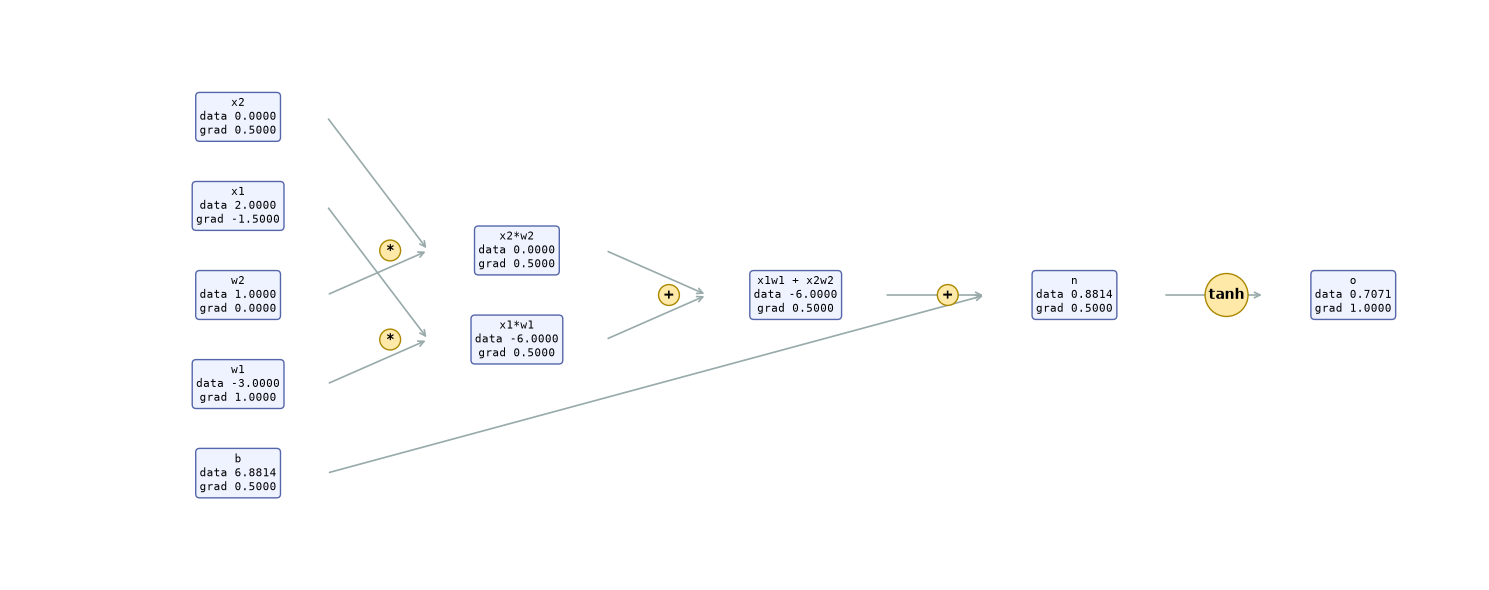

In [5]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
# bias (chosen so tanh lands in a nicely non-saturated region)
b  = Value(6.8813735870195432, label='b')

x1w1 = x1*w1;        x1w1.label = 'x1*w1'
x2w2 = x2*w2;        x2w2.label = 'x2*w2'
n_pre = x1w1 + x2w2; n_pre.label = 'x1w1 + x2w2'
n = n_pre + b;       n.label = 'n'
o = n.tanh();        o.label = 'o'

o.backward()         # fill in every .grad
draw_dot(o)

## 12. Backprop by hand, then automatically

Let's verify the engine by differentiating the neuron **by hand**, output-to-input, and matching `.grad`.

Start at the top with the seed $\frac{\partial o}{\partial o}=1$, then walk down:

$$\frac{\partial o}{\partial n} = 1 - \tanh^2(n) = 1 - o^2.$$

`n = (x_1w_1 + x_2w_2) + b` is all additions, which **route** the gradient unchanged, so each of
`x1w1`, `x2w2`, and `b` inherits $\frac{\partial o}{\partial n}$. Then each product splits via the
product rule — the gradient of `x1*w1` flows to `x1` scaled by `w1`, and to `w1` scaled by `x1`:

$$\frac{\partial o}{\partial w_1} = \frac{\partial o}{\partial n}\cdot x_1, \qquad
  \frac{\partial o}{\partial x_1} = \frac{\partial o}{\partial n}\cdot w_1.$$

In [6]:
dn = 1 - o.data**2          # do/dn = 1 - tanh(n)^2
print("by hand   do/dn  =", dn,            " | engine n.grad  =", n.grad)
print("by hand   do/db  =", dn,            " | engine b.grad  =", b.grad)
print("by hand   do/dw1 =", dn * x1.data,  " | engine w1.grad =", w1.grad)
print("by hand   do/dx1 =", dn * w1.data,  " | engine x1.grad =", x1.grad)
print("by hand   do/dw2 =", dn * x2.data,  " | engine w2.grad =", w2.grad)

assert abs(n.grad  - dn)            < 1e-9
assert abs(w1.grad - dn * x1.data)  < 1e-9
assert abs(x1.grad - dn * w1.data)  < 1e-9
print("\nhand-derived gradients match the engine.")

by hand   do/dn  = 0.4999999999999999  | engine n.grad  = 0.4999999999999999
by hand   do/db  = 0.4999999999999999  | engine b.grad  = 0.4999999999999999
by hand   do/dw1 = 0.9999999999999998  | engine w1.grad = 0.9999999999999998
by hand   do/dx1 = -1.4999999999999996  | engine x1.grad = -1.4999999999999996
by hand   do/dw2 = 0.0  | engine w2.grad = 0.0

hand-derived gradients match the engine.


## 13. Check against PyTorch — external ground truth

Our engine should agree with a mature autodiff library to the last decimal. We rebuild the **same** neuron with `torch` tensors (using `.double()` for an exact comparison), call PyTorch's `backward()`, and diff the gradients. If `torch` isn't installed the cell skips gracefully.

In [7]:
try:
    import torch

    tx1 = torch.tensor([2.0],  dtype=torch.double, requires_grad=True)
    tx2 = torch.tensor([0.0],  dtype=torch.double, requires_grad=True)
    tw1 = torch.tensor([-3.0], dtype=torch.double, requires_grad=True)
    tw2 = torch.tensor([1.0],  dtype=torch.double, requires_grad=True)
    tb  = torch.tensor([6.8813735870195432], dtype=torch.double, requires_grad=True)

    tn = tx1*tw1 + tx2*tw2 + tb
    to = torch.tanh(tn)
    to.backward()

    print(f"{'':6} {'micrograd':>14} {'pytorch':>14}")
    for name, mine, tt in [('x1', x1, tx1), ('w1', w1, tw1),
                           ('x2', x2, tx2), ('w2', w2, tw2), ('b', b, tb)]:
        print(f"{name:6} {mine.grad:14.10f} {tt.grad.item():14.10f}")
        assert abs(mine.grad - tt.grad.item()) < 1e-9
    print(f"\nforward o:  micrograd={o.data:.10f}  pytorch={to.item():.10f}")
    print("PyTorch agrees to 1e-9.")
except ModuleNotFoundError:
    print("torch not installed - skipping the cross-check (the engine still stands on its own).")

            micrograd        pytorch
x1      -1.5000000000  -1.5000000000
w1       1.0000000000   1.0000000000
x2       0.5000000000   0.5000000000
w2       0.0000000000   0.0000000000
b        0.5000000000   0.5000000000

forward o:  micrograd=0.7071067812  pytorch=0.7071067812
PyTorch agrees to 1e-9.


## 14. The two classic bugs — why gradients **accumulate**

These are the bugs everyone hits when first writing micrograd. Understanding them *is* understanding the
backward pass.

**Bug 1 — `self.grad = ...` instead of `self.grad += ...`.** Consider a node used **twice**, e.g.
$y = a + a$. Mathematically $\frac{dy}{da}=2$: gradient arrives along *two* edges and the chain rule says
they **add**. If `_backward` overwrites with `=`, the second contribution clobbers the first and you get
$1$. With `+=`, you correctly get $2$. The same thing happens for *any* shared sub-expression — and in a
real network, weights feed many downstream nodes — so `+=` is not optional.

**Bug 2 — `__truediv__` returning `self * other` instead of `self * other**-1`.** Division is
multiplication by a reciprocal, $a/b = a\cdot b^{-1}$. Returning `self * other` computes a *product*, not a
quotient: the forward value is wrong, so every gradient built on top of it is wrong too.

The cell below demonstrates both: the shared-node gradient comes out to $2$ (Bug 1 fixed), and division
agrees with the analytic derivative (Bug 2 fixed).

In [8]:
# Bug 1: a node reused twice -- gradient must ACCUMULATE to 2, not stay at 1.
a = Value(3.0, label='a')
y = a + a; y.label = 'y'
y.backward()
print("d(a+a)/da =", a.grad, " (expected 2 -- needs += in _backward)")
assert a.grad == 2.0

# A longer shared path: f = a*b + a  ->  df/da = b + 1
a = Value(3.0); b = Value(4.0)
f = a*b + a
f.backward()
print("d(a*b+a)/da =", a.grad, " (expected b+1 = 5)")
assert a.grad == 5.0

# Bug 2: division is a*b**-1.  d(a/b)/da = 1/b ;  d(a/b)/db = -a/b^2
a = Value(6.0); b = Value(2.0)
q = a / b
q.backward()
print(f"a/b      = {q.data}  (expected 3.0)")
print(f"d/da a/b = {a.grad}  (expected 1/b   = {1/2:.4f})")
print(f"d/db a/b = {b.grad}  (expected -a/b^2 = {-6/4:.4f})")
assert abs(q.data - 3.0) < 1e-9 and abs(a.grad - 0.5) < 1e-9 and abs(b.grad + 1.5) < 1e-9
print("both bugs are absent from our class.")

d(a+a)/da = 2.0  (expected 2 -- needs += in _backward)
d(a*b+a)/da = 5.0  (expected b+1 = 5)
a/b      = 3.0  (expected 3.0)
d/da a/b = 0.5  (expected 1/b   = 0.5000)
d/db a/b = -1.5  (expected -a/b^2 = -1.5000)
both bugs are absent from our class.


## 15. Neuron → Layer → MLP — a network on top of the engine

Now stack the scalar engine into a real network. The biological metaphor: dendrites carry inputs $x_i$,
each scaled by a synaptic strength $w_i$; the soma sums them with a bias $b$ and "fires" through an
activation. In math, a **neuron** computes

$$o = \tanh\!\Big(\textstyle\sum_i w_i x_i + b\Big).$$

Crucially, $w_i$ and $b$ are `Value`s, so they're part of the graph — calling `.backward()` on a loss will
populate `w.grad` and `b.grad` for **every** neuron automatically.

- **`Neuron(nin)`** — `nin` weights + 1 bias; `__call__(x)` returns one `Value`.
- **`Layer(nin, nout)`** — `nout` independent neurons sharing the same inputs.
- **`MLP(nin, nouts)`** — a list of layers chained together (the output of one feeds the next).

`parameters()` flattens out every `Value` we need to train — the things gradient descent will nudge.

In [9]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)   # w . x + b
        return act.tanh()                                          # non-linearity

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

model = MLP(3, [4, 4, 1])     # 3 inputs -> 4 -> 4 -> 1 output
print(model(Value(2.0), )    if False else "")
print("a 3->4->4->1 MLP has", len(model.parameters()), "trainable parameters")


a 3->4->4->1 MLP has 41 trainable parameters


## 16. The prediction problem — a tiny labelled dataset

To *use the network for prediction* we need data: input vectors `xs` and the targets `ys` we want the
network to output. This is the classic micrograd toy set — four 3-dimensional points, each labelled
$+1$ or $-1$ (a binary classification problem the $\tanh$ output, which lives in $(-1, 1)$, can fit).

In [10]:
xs = [
    [ 2.0,  3.0, -1.0],
    [ 3.0, -1.0,  0.5],
    [ 0.5,  1.0,  1.0],
    [ 1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]    # desired target for each row

print("predictions BEFORE training (random weights):")
for x, ygt in zip(xs, ys):
    print(f"  x={x}  pred={model(x).data:+.4f}   target={ygt:+.1f}")

predictions BEFORE training (random weights):
  x=[2.0, 3.0, -1.0]  pred=+0.4277   target=+1.0
  x=[3.0, -1.0, 0.5]  pred=+0.5571   target=-1.0
  x=[0.5, 1.0, 1.0]  pred=+0.7185   target=-1.0
  x=[1.0, 1.0, -1.0]  pred=+0.4520   target=+1.0


## 17. Loss — turning four predictions into one number to minimize

Gradient descent minimizes a **single scalar**. We summarize "how wrong is the network over the whole
dataset" with **mean-squared error** (here a sum of squared errors):

$$L = \sum_{j} \big(\hat y_j - y_j\big)^2,$$

where $\hat y_j$ is the prediction for example $j$ and $y_j$ its target. Squaring makes every term
non-negative and punishes large misses harder; $L=0$ only when every prediction is exactly right. Because
$L$ is built entirely from `Value` operations, **its graph connects back to every weight**, so
`L.backward()` gives us $\frac{\partial L}{\partial \theta}$ for all parameters at once.

In [11]:
def loss_fn(model, xs, ys):
    ypred = [model(x) for x in xs]
    return sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), ypred

L, _ = loss_fn(model, xs, ys)
print("initial loss =", L.data)

initial loss = 6.005402783252284


## 18. Gradient descent — the training loop

One step of learning is three moves:

1. **Forward** — compute predictions and the loss $L$.
2. **Backward** — `L.backward()` fills every `p.grad` with $\frac{\partial L}{\partial p}$.
3. **Update** — nudge each parameter a little *against* its gradient:

$$\theta \leftarrow \theta - \eta\,\frac{\partial L}{\partial \theta}.$$

The minus sign points us **downhill** (the gradient points uphill); $\eta$ (the *learning rate*) sets the
step size. The one easy-to-forget detail: **zero the gradients first**. Because `_backward` uses `+=`,
grads from the previous step would otherwise pile onto this step's — so each iteration starts by setting
every `p.grad = 0.0`. That's the same accumulation behaviour from §14, now something we must actively
reset.

In [12]:
lr = 0.1
history = []
for step in range(100):
    # 1. forward
    L, ypred = loss_fn(model, xs, ys)

    # 2. backward  (zero grads first -- they accumulate!)
    for p in model.parameters():
        p.grad = 0.0
    L.backward()

    # 3. update: step each parameter downhill
    for p in model.parameters():
        p.data += -lr * p.grad

    history.append(L.data)
    if step % 10 == 0 or step == 99:
        print(f"step {step:3d}   loss {L.data:.6f}")

step   0   loss 6.005403
step  10   loss 0.053355
step  20   loss 0.016507
step  30   loss 0.009512
step  40   loss 0.006618
step  50   loss 0.005050
step  60   loss 0.004071


step  70   loss 0.003404

step  80   loss 0.002921
step  90   loss 0.002555
step  99   loss 0.002295


## 19. Watch the predictions converge

The loss should fall toward zero, and the four predictions should snap to their $\pm1$ targets — the network is now **making correct predictions** on the data it was trained on.

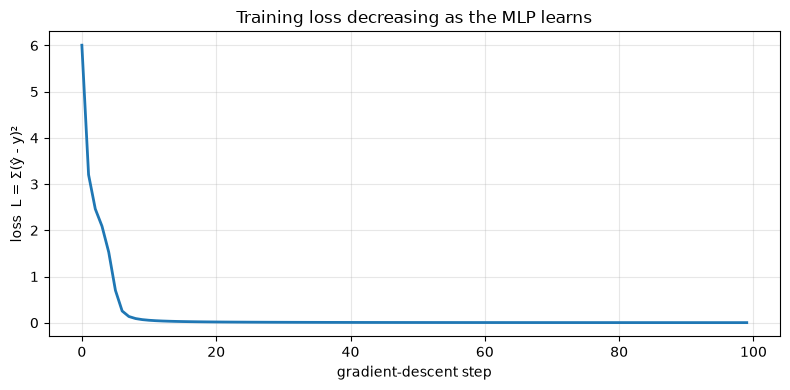

predictions AFTER training:
  x=[2.0, 3.0, -1.0]  pred=+0.9727   target=+1.0   [OK]
  x=[3.0, -1.0, 0.5]  pred=-0.9940   target=-1.0   [OK]
  x=[0.5, 1.0, 1.0]  pred=-0.9734   target=-1.0   [OK]
  x=[1.0, 1.0, -1.0]  pred=+0.9720   target=+1.0   [OK]

final loss = 0.002295


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, lw=2)
ax.set_xlabel('gradient-descent step'); ax.set_ylabel('loss  L = Σ(ŷ - y)²')
ax.set_title('Training loss decreasing as the MLP learns'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("predictions AFTER training:")
for x, ygt in zip(xs, ys):
    pred = model(x).data
    flag = 'OK' if (pred > 0) == (ygt > 0) else 'XX'
    print(f"  x={x}  pred={pred:+.4f}   target={ygt:+.1f}   [{flag}]")
print(f"\nfinal loss = {history[-1]:.6f}")

## 20. Summary — concept → code map

| Concept | The math | Where it lives in the code |
|---|---|---|
| A differentiable scalar | $f$ and $\frac{\partial L}{\partial f}$ | `Value.data`, `Value.grad` |
| Local derivative of an op | $\frac{\partial f}{\partial u}$ | each op's `_backward` closure |
| Addition routes gradient | $\partial(a{+}b)=1$ each | `__add__` |
| Multiplication swaps factors | product rule | `__mul__` |
| Power / division / sqrt | $n x^{n-1}$ | `__pow__` (+ `__truediv__`) |
| Non-linearity | $\tanh' = 1-\tanh^2$ | `tanh`, `exp` |
| Whole-graph differentiation | reverse-topological chain rule | `backward()` |
| Gradients add over paths | multivariable chain rule | `+=` in every `_backward` |
| A neuron | $\tanh(\mathbf w\!\cdot\!\mathbf x + b)$ | `Neuron` |
| A network | composition of layers | `Layer`, `MLP` |
| How wrong are we | $L=\sum(\hat y-y)^2$ | `loss_fn` |
| Learning | $\theta \leftarrow \theta-\eta\nabla_\theta L$ | the training loop |

**The one-sentence version.** A `Value` remembers how it was built; `backward()` walks that history in
reverse, multiplying local derivatives (the chain rule) to get $\frac{\partial L}{\partial \theta}$ for
every parameter; gradient descent steps those parameters downhill; repeat, and the network learns to
**predict**. Everything else in deep learning — bigger graphs, more ops, fancier optimizers — is this same
loop, scaled up.